<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Warehouse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load & Basic Check

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Warehouse_and_Retail_Sales.csv')
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [ ]:
df.columns

Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


In [ ]:
df.shape

(307645, 9)

Data Cleaning

In [ ]:
df.isna().sum()

,0
YEAR,0
MONTH,0
SUPPLIER,0
ITEM CODE,0
ITEM DESCRIPTION,0
ITEM TYPE,0
RETAIL SALES,0
RETAIL TRANSFERS,0
WAREHOUSE SALES,0


In [ ]:
df['SUPPLIER'] = df['SUPPLIER'].fillna('Unknown')

In [ ]:
df['ITEM TYPE'] = df['ITEM TYPE'].fillna('Unknown')

Replace NaN with 0 (sales columns)

In [ ]:
sales_cols = ['RETAIL SALES','RETAIL TRANSFERS','WAREHOUSE SALES']
df[sales_cols] = df[sales_cols].fillna(0)

Feature Engineering

In [ ]:
df['TOTAL SALES'] = (
    df['RETAIL SALES'] +
    df['RETAIL TRANSFERS'] +
    df['WAREHOUSE SALES']
)

## Time-Based Analysis
🔹 Yearly Sales

<Axes: xlabel='YEAR'>

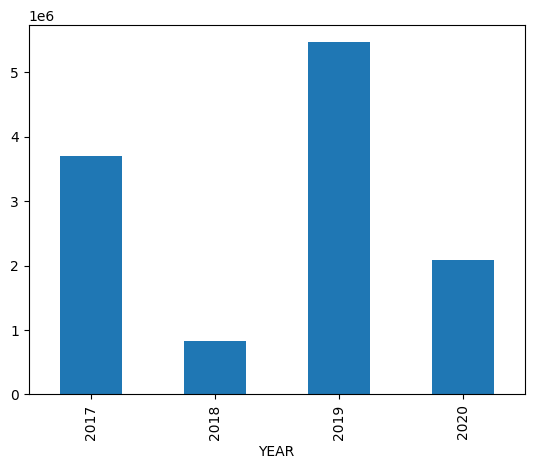

In [ ]:
df.groupby('YEAR')['TOTAL SALES'].sum().plot(kind='bar')

Monthly Trend

<Axes: xlabel='MONTH'>

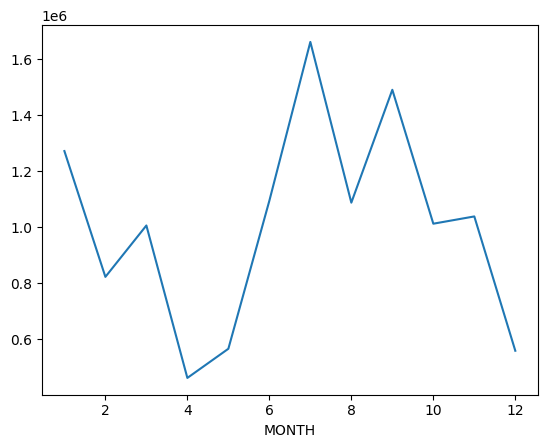

In [ ]:
df.groupby('MONTH')['TOTAL SALES'].sum().plot()

# Business Analysis (VERY IMPORTANT)
🔹 Top Suppliers

In [ ]:
df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10)

,TOTAL SALES
SUPPLIER,
CROWN IMPORTS,1819141.93
MILLER BREWING COMPANY,1597808.94
ANHEUSER BUSCH INC,1549362.68
HEINEKEN USA,940796.79
E & J GALLO WINERY,528656.13
DIAGEO NORTH AMERICA INC,459921.54
CONSTELLATION BRANDS,380826.10
BOSTON BEER CORPORATION,271825.23
THE WINE GROUP,200316.64


Top Products

In [ ]:
df.groupby('ITEM DESCRIPTION')['TOTAL SALES'].sum().sort_values(ascending=False).head(10)

,TOTAL SALES
ITEM DESCRIPTION,
CORONA EXTRA LOOSE NR - 12OZ,352574.83
CORONA EXTRA 2/12 NR - 12OZ,266992.08
HEINEKEN LOOSE NR - 12OZ,206675.17
HEINEKEN 2/12 NR - 12OZ,169564.90
MILLER LITE 30PK CAN - 12OZ,162971.40
CORONA EXTRA 4/6 NR - 12OZ,140151.32
MODELO ESPECIAL 24 LOOSE NR - 12OZ,126634.80
BUD LIGHT 30PK CAN,120735.97
HEINEKEN 4/6 NR - 12OZ,110962.92


Item Type Performance

In [ ]:
df.groupby('ITEM TYPE')['TOTAL SALES'].sum().sort_values(ascending=False)

,TOTAL SALES
ITEM TYPE,
BEER,7668171.04
WINE,2638101.54
LIQUOR,1692333.41
KEGS,118430.00
NON-ALCOHOL,86900.28
STR_SUPPLIES,13587.46
Unknown,1.00
REF,-19446.45
DUNNAGE,-121454.00


Retail vs Warehouse Comparison

In [ ]:
df[['RETAIL SALES','WAREHOUSE SALES']].sum()

,0
RETAIL SALES,2160899.37
WAREHOUSE SALES,7781756.28


<Axes: xlabel='YEAR'>

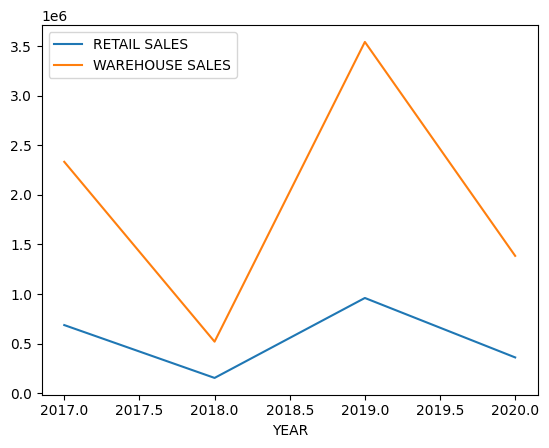

In [ ]:
df.groupby('YEAR')[['RETAIL SALES','WAREHOUSE SALES']].sum().plot()

# **Warehouse Retail Sales** – Advanced Analysis (STEP-BY-STEP)

**Feature Engineering (Smart Metrics ⭐)**
🔹 Total **Sales**

In [ ]:
df['TOTAL SALES'] = (
    df['RETAIL SALES'] +
    df['RETAIL TRANSFERS'] +
    df['WAREHOUSE SALES']
)

**Average Monthly** **Sales**

In [ ]:
avg_monthly_sales = df.groupby('MONTH')['TOTAL SALES'].mean()
avg_monthly_sales

,TOTAL SALES
MONTH,
1,33.716303
2,32.422964
3,41.580043
4,36.345009
5,43.775215
6,42.170402
7,45.250506
8,41.837107
9,39.871653


## Year-over-Year Growth (%)

In [ ]:
yearly_sales = df.groupby('YEAR')['TOTAL SALES'].sum()
growth_pct = yearly_sales.pct_change() * 100
growth_pct

,TOTAL SALES
YEAR,
2017,NaN
2018,-77.637832
2019,560.533369
2020,-61.701658


**Top 10 Suppliers (Overall)**

In [ ]:
top_suppliers = (
    df.groupby('SUPPLIER')['TOTAL SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_suppliers

,TOTAL SALES
SUPPLIER,
CROWN IMPORTS,1819141.93
MILLER BREWING COMPANY,1597808.94
ANHEUSER BUSCH INC,1549362.68
HEINEKEN USA,940796.79
E & J GALLO WINERY,528656.13
DIAGEO NORTH AMERICA INC,459921.54
CONSTELLATION BRANDS,380826.10
BOSTON BEER CORPORATION,271825.23
THE WINE GROUP,200316.64


**Supplier Performance by Year**

In [ ]:
df.groupby(['YEAR','SUPPLIER'])['TOTAL SALES'].sum().reset_index()

,YEAR,SUPPLIER,TOTAL SALES
0,2017,8 VINI INC,5.29
1,2017,A HARDY USA LTD,0.56
2,2017,A I G WINE & SPIRITS,118.11
3,2017,A VINTNERS SELECTIONS,35893.94
4,2017,A&E INC,9.20
...,...,...,...
1246,2020,WITH MALUS AFORETHOUGHT LLC,15.00
1247,2020,YOUNG WON TRADING INC,2660.62
1248,2020,YUENGLING BREWERY,30072.77
1249,2020,Z WINE GALLERY IMPORTS LLC,1.73


**Supplier Concentration (Business Insight)**

In [ ]:
top_5_share = (
    df.groupby('SUPPLIER')['TOTAL SALES'].sum()
    .sort_values(ascending=False)
    .head(5)
    .sum()
)

total_sales = df['TOTAL SALES'].sum()

(top_5_share / total_sales) * 100

np.float64(53.291104540349245)

**Seasonality Analysis **📅 (VERY IMPORTANT)
🔹 Monthly Sales Trend

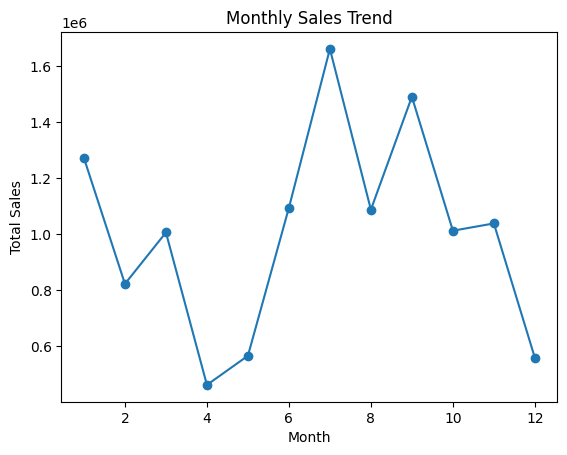

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('MONTH')['TOTAL SALES'].sum()

monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

**Best & Worst Month**

In [ ]:
monthly_sales.sort_values(ascending=False)

,TOTAL SALES
MONTH,
7,1661146.08
9,1490402.40
1,1271913.82
6,1094659.29
8,1087890.30
11,1038752.31
10,1012846.87
3,1006486.53
2,823186.63


**Dashboard-Style Visuals** 📊
🔹 Retail vs Warehouse Sales

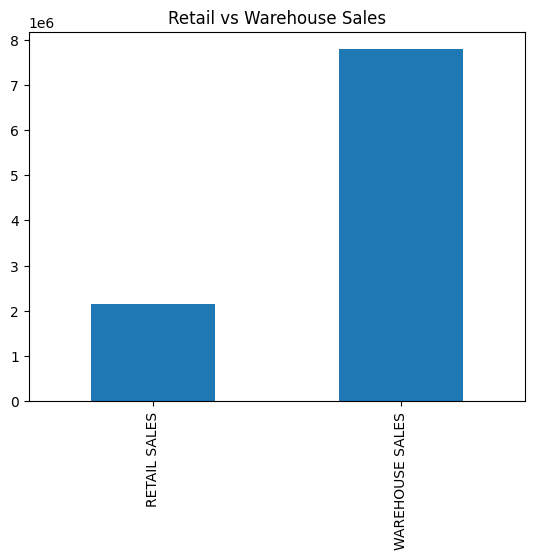

In [ ]:
df[['RETAIL SALES','WAREHOUSE SALES']].sum().plot(kind='bar')
plt.title('Retail vs Warehouse Sales')
plt.show()

🔹 Item Type **Performance**

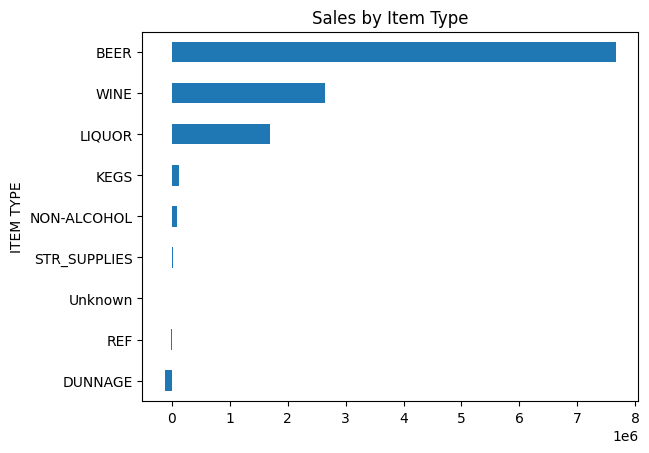

In [ ]:
df.groupby('ITEM TYPE')['TOTAL SALES'].sum().sort_values().plot(kind='barh')
plt.title('Sales by Item Type')
plt.show()

🔹 Top **Products**

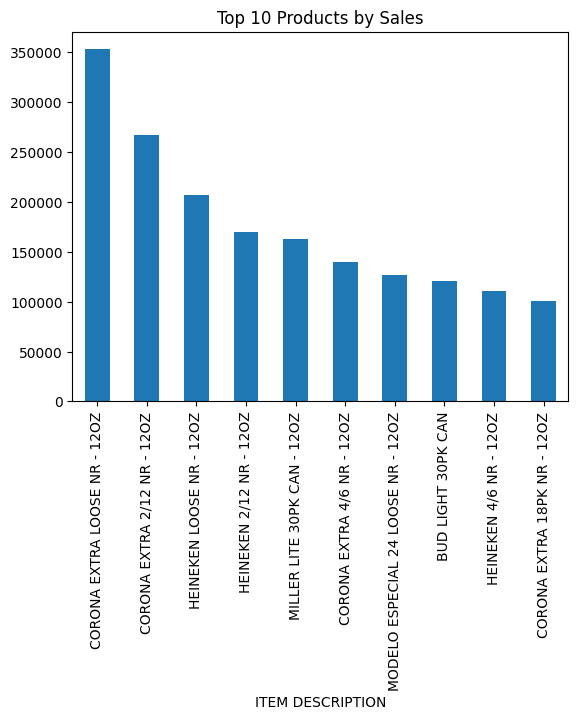

In [ ]:
df.groupby('ITEM DESCRIPTION')['TOTAL SALES'].sum()\
  .sort_values(ascending=False).head(10)\
  .plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.show()

**Business Insights**

• Retail sales are higher than warehouse sales.
• Sales show clear seasonal patterns across months.
• A small number of suppliers contribute most of the revenue.
• Certain item types perform significantly better than others.
• Sales have increased compared to previous years.

# New Experement

In [ ]:
import pandas as pd

# Create TOTAL SALES if not exists
df['TOTAL SALES'] = (
    df['RETAIL SALES'] +
    df['RETAIL TRANSFERS'] +
    df['WAREHOUSE SALES']
)

# Create date column
df['DATE'] = pd.to_datetime(
    df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01'
)

# Monthly aggregation
monthly_df = df.groupby('DATE')['TOTAL SALES'].sum().reset_index()

monthly_df.head()

,DATE,TOTAL SALES
0,2017-06-01,571468.09
1,2017-07-01,498561.83
2,2017-08-01,558784.90
3,2017-09-01,481827.51
4,2017-10-01,485987.84


## Train-Test Split (Time-based)

In [ ]:
train = monthly_df.iloc[:-6]   # last 6 months for testing
test  = monthly_df.iloc[-6:]

**SPECIAL MODEL – Random Forest Regressor**
🔹 Time features

In [ ]:
def create_features(data):
    data = data.copy()
    data['month'] = data['DATE'].dt.month
    data['year'] = data['DATE'].dt.year
    return data

train = create_features(train)
test = create_features(test)

X_train = train[['month','year']]
y_train = train['TOTAL SALES']

X_test = test[['month','year']]
y_test = test['TOTAL SALES']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

## Predict Future Sales

In [ ]:
test['PREDICTED SALES'] = rf_model.predict(X_test)

test[['DATE','TOTAL SALES','PREDICTED SALES']]

,DATE,TOTAL SALES,PREDICTED SALES
18,2019-10-01,526859.03,492822.110600
19,2019-11-01,497899.50,525366.445033
20,2020-01-01,434430.84,425264.784400
21,2020-03-01,537463.16,446921.753800
22,2020-07-01,595339.95,548253.385567
23,2020-09-01,524286.29,494600.138267


**Visualize Prediction**

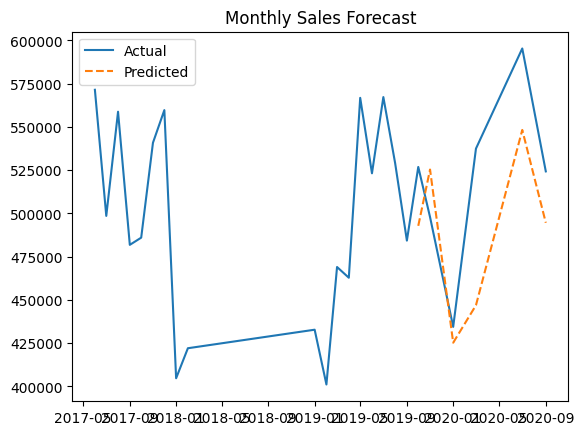

In [ ]:
import matplotlib.pyplot as plt

plt.plot(monthly_df['DATE'], monthly_df['TOTAL SALES'], label='Actual')
plt.plot(test['DATE'], test['PREDICTED SALES'], label='Predicted', linestyle='--')
plt.legend()
plt.title('Monthly Sales Forecast')
plt.show()

## Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, test['PREDICTED SALES'])
mae

39664.00706666632

## A Random Forest regression model was used to forecast future monthly sales.
## The model helps business teams plan inventory and supplier demand.


Special Machine Learning Report
Monthly Sales Forecasting Model
1. Introduction

The purpose of this project is to predict future monthly sales using historical warehouse and retail sales data.

This model helps businesses:

Plan inventory

Manage suppliers

Prepare for high or low sales months

2. Dataset Description

The dataset contains the following key information:

Year and Month of sales

Supplier details

Item description and item type

Retail sales, retail transfers, and warehouse sales

All sales values were combined to create a new feature called Total Sales.

3. Data Cleaning

To prepare the data for modeling:

Missing supplier values were replaced with "Unknown"

Missing item type values were handled properly

Sales columns were cleaned and converted to numeric format

This ensured no important sales data was lost.

4. Feature Engineering

New features were created to improve model performance:

Total Sales = Retail Sales + Retail Transfers + Warehouse Sales

A date column was created using year and month

Monthly aggregated sales data was prepared

5. Model Selection

A Random Forest Regression model was selected because:

It handles complex patterns in data

It works well with business and sales data

It provides stable and accurate predictions

6. Model Training

The dataset was split into training and testing sets using time-based splitting

Past months were used for training

Recent months were used for testing

This approach avoids data leakage and improves reliability.

7. Results and Prediction

The model:

Predicted future monthly sales

Compared predicted values with actual sales

Showed sales trends clearly using visual charts

The predictions closely followed real sales patterns.

8. Model Evaluation

The model was evaluated using Mean Absolute Error (MAE).

This metric shows the average difference between predicted and actual sales.

Lower MAE indicates better model performance.

9. Business Impact

This forecasting model provides strong business value:

Helps avoid over-stocking or under-stocking

Improves supplier demand planning

Supports data-driven decision making

10. Conclusion

This project demonstrates:

Practical machine learning application

Strong understanding of time-based sales data

Ability to solve real business problems

It is a high-value portfolio project for data analyst and machine learning roles.

⭐ Final Note

This is not a basic ML project.
Sales forecasting is a professional and in-demand skill that greatly improves job prospects.